In [1]:
# !pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import (classification_report, confusion_matrix, average_precision_score, PrecisionRecallDisplay, precision_recall_curve, 
                             roc_auc_score, recall_score, cohen_kappa_score)

In [3]:
# =====================
# 1. Prepare Data
# =====================
# df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df = pd.read_csv('/workspaces/malnutrition/Dataset/ch.csv')
df = df.drop(columns=['child weight'])

X = df.drop(columns=['status'])
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# print("Before SMOTE:", Counter(y_train))
# print("After SMOTE:", Counter(y_train_sm))

In [4]:
df.head()

,child age,diarrhoea,fever,area,child sex,mother education,health insurance,wealth index,status,gandaki,karnali,koshi,madhesh,lumbini,sudurpashchim
0,1.0,0,0,0,1,2.0,1,1.0,1,0,0,1,0,0,0
1,3.0,0,1,0,1,2.0,1,1.0,1,0,0,1,0,0,0
2,2.0,1,0,0,0,1.0,1,1.0,0,0,0,1,0,0,0
3,1.0,1,1,0,0,1.0,1,1.0,0,0,0,1,0,0,0
4,4.0,0,0,0,0,1.0,1,1.0,0,0,0,1,0,0,0


## Base Model

In [5]:
# =====================
# 2. Base Model with SMOTE outside pipeline
# =====================
base_lr = LogisticRegression(solver='liblinear', random_state=42)
base_lr.fit(X_train_sm, y_train_sm)

y_pred_base = base_lr.predict(X_test)
y_proba_base = base_lr.predict_proba(X_test)[:, 1]
y_train_pred_base = base_lr.predict(X_train_sm)

# Evaluation
print(confusion_matrix(y_test, y_pred_base))
print("------------------------------------------------------")
print(classification_report(y_test, y_pred_base, digits=3))
print("------------------------------------------------------")
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_base):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_base):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_base):.3f}")
print(f"Training recall: {recall_score(y_train_sm, y_train_pred_base):.3f}")

[[394 313]
 [230 374]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.631     0.557     0.592       707
           1      0.544     0.619     0.579       604

    accuracy                          0.586      1311
   macro avg      0.588     0.588     0.586      1311
weighted avg      0.591     0.586     0.586      1311

------------------------------------------------------
Test Avg Precision: 0.582
Test AUC: 0.623
Test Cohen's Kappa: 0.175
Training recall: 0.624


## Tuned Model

In [6]:
# Define pipeline
pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

# Define full parameter grid (including solver and penalty)
param_grid = [
    {
        'lr__penalty': ['l1'],
        'lr__solver': ['liblinear', 'saga'],
        'lr__C': [0.01, 0.1, 1, 10]
    },
    {
        'lr__penalty': ['l2'],
        'lr__solver': ['lbfgs', 'liblinear', 'saga'],
        'lr__C': [0.01, 0.1, 1, 10]
    },
    {
        'lr__penalty': ['elasticnet'],
        'lr__solver': ['saga'],
        'lr__C': [0.01, 0.1, 1, 10],
        'lr__l1_ratio': [0.1, 0.5, 0.9]  # Only relevant for elasticnet
    }
]

# Run GridSearchCV
grid_lr = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='recall',
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
,
    verbose=2,
    n_jobs=-1
)

# Fit the model
grid_lr.fit(X_train, y_train)

# Predict and evaluate
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)
y_proba_tune = best_lr.predict_proba(X_test)[:, 1]

# Scores for tuned model
print("Best Parameters:", grid_lr.best_params_)
print('------------------------------------------------------')
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, digits=3))

y_train_pred_lr = best_lr.predict(X_train)

print('------------------------------------------------------')
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_tune):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_tune):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_lr):.3f}")
print(f"Training recall: {recall_score(y_train, y_train_pred_lr):.3f}")

Fitting 15 folds for each of 32 candidates, totalling 480 fits


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf in

[CV] END ...lr__C=0.01, lr__penalty=l1, lr__solver=liblinear; total time=   0.4s
[CV] END ...lr__C=0.01, lr__penalty=l1, lr__solver=liblinear; total time=   0.4s


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf in

[CV] END ...lr__C=0.01, lr__penalty=l1, lr__solver=liblinear; total time=   0.2s
[CV] END ...lr__C=0.01, lr__penalty=l1, lr__solver=liblinear; total time=   0.2s
[CV] END ...lr__C=0.01, lr__penalty=l1, lr__solver=liblinear; total time=   0.2s


...

[CV] END lr__C=10, lr__l1_ratio=0.9, lr__penalty=elasticnet, lr__solver=saga; total time=  10.1s


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END lr__C=10, lr__l1_ratio=0.9, lr__penalty=elasticnet, lr__solver=saga; total time=  10.8s


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Parameters: {'lr__C': 0.01, 'lr__l1_ratio': 0.5, 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}
------------------------------------------------------
[[357 350]
 [206 398]]
              precision    recall  f1-score   support

           0      0.634     0.505     0.562       707
           1      0.532     0.659     0.589       604

    accuracy                          0.576      1311
   macro avg      0.583     0.582     0.575      1311
weighted avg      0.587     0.576     0.574      1311

------------------------------------------------------
Test Avg Precision: 0.569
Test AUC: 0.620
Test Cohen's Kappa: 0.161
Training recall: 0.673


### 95% CI on Recall

Recall 95% CI: (0.580, 0.658)


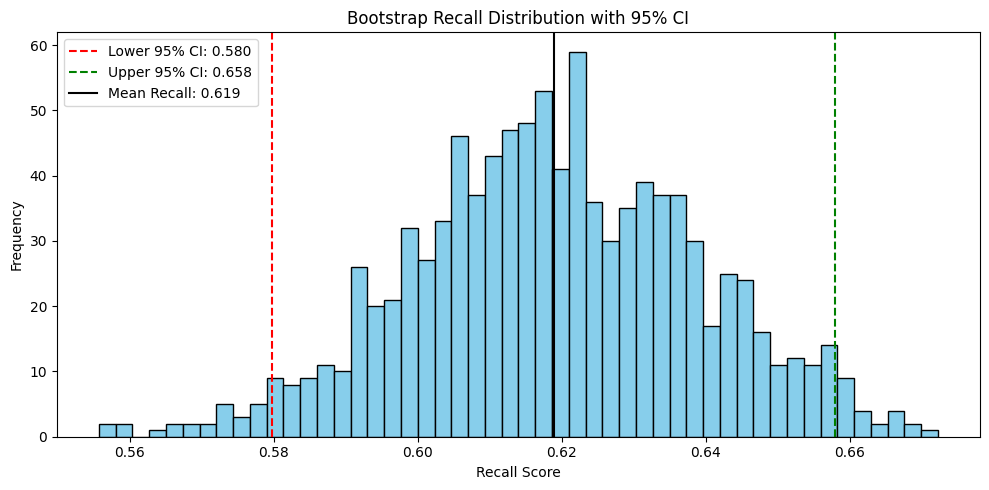

In [7]:
def bootstrap_ci_recall_distribution(y_true, y_pred_func, X, n_bootstraps=1000, alpha=0.95):
    rng = np.random.RandomState(42)
    bootstrapped_scores = []
    n = len(y_true)
    for _ in range(n_bootstraps):
        indices = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true.iloc[indices])) < 2:
            continue
        score = recall_score(y_true.iloc[indices], y_pred_func(X.iloc[indices]))
        bootstrapped_scores.append(score)
    sorted_scores = np.sort(bootstrapped_scores)
    lower = np.percentile(sorted_scores, ((1-alpha)/2)*100)
    upper = np.percentile(sorted_scores, (alpha + (1-alpha)/2)*100)
    return bootstrapped_scores, lower, upper

# scores
recall_scores, lower_ci, upper_ci = bootstrap_ci_recall_distribution(
    y_test.reset_index(drop=True), 
    base_lr.predict,  #calculated on base model because base model is better than tuned model
    X_test.reset_index(drop=True)
)

print(f"Recall 95% CI: ({lower_ci:.3f}, {upper_ci:.3f})")

# plot
plt.figure(figsize=(10, 5))
plt.hist(recall_scores, bins=50, color='skyblue', edgecolor='black')
plt.axvline(lower_ci, color='red', linestyle='--', label=f"Lower 95% CI: {lower_ci:.3f}")
plt.axvline(upper_ci, color='green', linestyle='--', label=f"Upper 95% CI: {upper_ci:.3f}")
plt.axvline(np.mean(recall_scores), color='black', linestyle='-', label=f"Mean Recall: {np.mean(recall_scores):.3f}")
plt.title("Bootstrap Recall Distribution with 95% CI")
plt.xlabel("Recall Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Feature importance

Logistic Regression naturally supports feature importance because it is a linear model. The model coefficients (coef_) can be interpreted as the impact of each feature on the log-odds of the positive class.

             Feature      Base
0          child age  0.019490
1          diarrhoea -0.008070
2              fever -0.082560
3               area -0.202537
4          child sex  0.120471
5   mother education -0.207354
6   health insurance  0.311515
7       wealth index -0.108673
8            gandaki -0.197720
9            karnali  0.675065
10             koshi -0.062389
11           madhesh  0.543332
12           lumbini  0.398823
13     sudurpashchim  0.519278


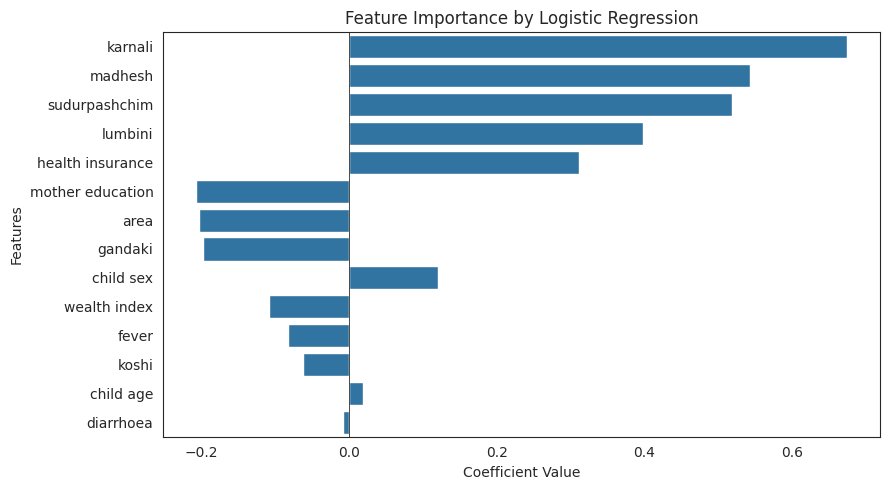

In [8]:
# Extract coefficients for base model only
coef_base = base_lr.coef_[0]

# Build DataFrame for base model only
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Base': coef_base
})

# Take top 5 features based on absolute base coefficients
top_features = importance_df.loc[np.abs(importance_df['Base']).argsort()]['Feature'].tolist()
filtered_df = importance_df[importance_df['Feature'].isin(top_features)]

# Sort features by absolute coefficient value
feature_order = (filtered_df.set_index('Feature')['Base']
                 .abs()
                 .sort_values(ascending=False)
                 .index)

print(filtered_df)

# ====================
# Plot
# ====================

sns.set_style("white")
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=filtered_df,
    y='Feature',
    x='Base',
    order=feature_order,
)

# # Coefficient labels
# for container in ax.containers:
#     ax.bar_label(container, fmt="%.3f", label_type="edge", fontsize=9, padding=3)

# Add titles and labels
plt.title('Feature Importance by Logistic Regression')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.ylabel('Features')
plt.yticks() 
plt.xticks()
plt.tight_layout()
plt.show()


### Average precision

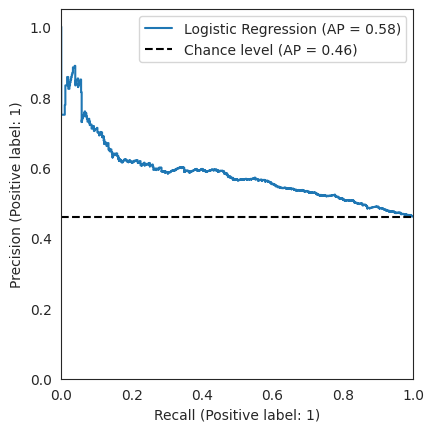

In [9]:
display = PrecisionRecallDisplay.from_estimator(
    base_lr,            # Trained model
    X_test,              # Test features
    y_test,              # True labels
    name="Logistic Regression",          # Name for legend
    plot_chance_level=True  # Automatically plots chance-level baseline
)

# display.ax_.set_title("Precision-Recall curve")
display.ax_.legend(loc='upper right')
display.ax_.set_xlim([0.0, 1.0])
display.ax_.set_ylim([0.0, 1.05])
plt.show()

### Additional

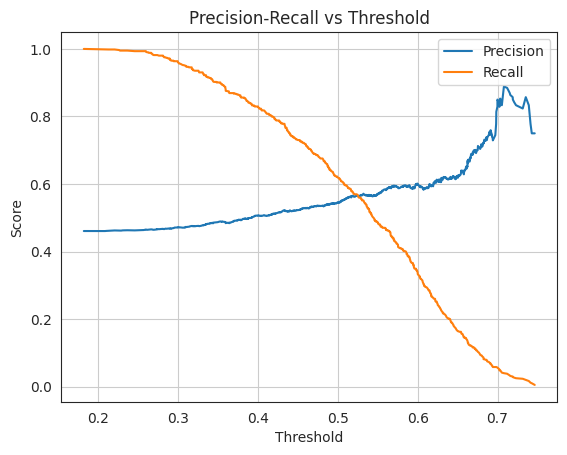

In [10]:
y_proba_tune = base_lr.predict_proba(X_test)[:, 1]       #Probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_tune)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [11]:
# Apply custom threshold
y_proba_custom = (y_proba_tune >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_proba_custom, digits = 3)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0      0.681     0.311     0.427       707
           1      0.507     0.829     0.629       604

    accuracy                          0.550      1311
   macro avg      0.594     0.570     0.528      1311
weighted avg      0.601     0.550     0.520      1311


